In [39]:
import os
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

# Fix random seeds → ensures reproducibility across runs
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cuda


In [40]:
# Data Paths & Hyperparams


DATASET_PATH = "/kaggle/input/datasets/felpspotenza/eeg-dataset/eeg_trials_results"
EEG_PATH = "/kaggle/input/datasets/felpspotenza/eeg-dataset/eeg_preprocessed"

# All subject pairs (as in original dataset)
PAIR_IDS = list(range(1, 10)) + list(range(11, 23)) + list(range(25, 35))

# Targets:
# self, other, previous self, previous other
TARGET_COLS = [0, 1, 2, 3]
TARGET_NAMES = ["self", "other", "self_prev", "other_prev"]

# Temporal window size for CNN input
WINDOW = 3  # ~750ms → balances noise reduction vs temporal precision

# Time binning (250 ms bins, matching paper)
TIME_WINDOWS_AB = np.column_stack([np.arange(0,2,0.25), np.arange(0.25,2.25,0.25)])
TIME_WINDOWS_C  = np.column_stack([np.arange(0,1,0.25), np.arange(0.25,1.25,0.25)])

# Construct full timeline (Decision + Response + Feedback)
time_labels = np.concatenate([
    TIME_WINDOWS_AB[:,1],
    TIME_WINDOWS_AB[:,1] + 2,
    TIME_WINDOWS_C[:,1] + 4
])

In [41]:
# EEG → TIME-BINNED REPRESENTATION

def epoch_to_timebinned_array(epochs):
    
    """
    Converts continuous EEG epochs into 250 ms averaged time bins.

    Split:
    Decision (0–2s), Response (2–4s), Feedback (4–5s)
    """

    data = epochs.get_data()
    times = epochs.times

    def bin_part(d, t, windows):
        out = np.zeros((d.shape[0], d.shape[1], len(windows)))
        for i, (t0, t1) in enumerate(windows):
            mask = (t > t0) & (t < t1)

            # Sanity check
            assert mask.sum() > 0, "if Empty time bin check window definition"

            out[:, :, i] = d[:, :, mask].mean(axis=2)
        return out

    # Split phases
    A = data[:, :, (times >= -0.2) & (times <= 2)]
    B = data[:, :, (times >= 1.8) & (times <= 4)]
    C = data[:, :, (times >= 3.8) & (times <= 5)]

    tA = times[(times >= -0.2) & (times <= 2)]
    tB = times[(times >= 1.8) & (times <= 4)] - 2
    tC = times[(times >= 3.8) & (times <= 5)] - 4

    A = bin_part(A, tA, TIME_WINDOWS_AB)
    B = bin_part(B, tB, TIME_WINDOWS_AB)
    C = bin_part(C, tC, TIME_WINDOWS_C)

    data = np.concatenate([A, B, C], axis=2)

    # Sanity check
    assert data.shape[2] == 20, "Expected 20 time bins (8+8+4)"

    return data

In [42]:
# BEHAVIOURAL TARGET CONSTRUCTION

def build_behaviour(events):
    """
    Constructs decoding targets.

    WHY:
    - Includes both current and previous decisions
    - Allows testing memory-related signals
    """

    p1 = events["player1_resp"].values
    p2 = events["player2_resp"].values

    p1_prev = np.concatenate([[np.nan], p1[:-1]])
    p2_prev = np.concatenate([[np.nan], p2[:-1]])

    return [
        np.column_stack([p1, p2, p1_prev, p2_prev]),
        np.column_stack([p2, p1, p2_prev, p1_prev])
    ]

In [43]:
def make_pseudotrials(X, y, n_avg=4):

    X_new, y_new = [], []

    for c in np.unique(y):
        idx = np.where(y == c)[0]
        np.random.shuffle(idx)

        for i in range(0, len(idx)-n_avg, n_avg):
            sel = idx[i:i+n_avg]
            X_new.append(X[sel].mean(axis=0))
            y_new.append(c)

    return np.array(X_new), np.array(y_new)

In [44]:
# EEGNet MODEL


class EEGNet(nn.Module):
    """
    Lightweight CNN for EEG decoding.


    - Designed and inspired from the EEGnet paper (spatial + temporal filters)

    """

    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1,32,(1,5),padding=(0,2)),  # temporal filters
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.Dropout(0.3),

            nn.Conv2d(32,64,(1,5),padding=(0,2)),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.Dropout(0.3),

            nn.Conv2d(64,64,(n_channels,1)),  # spatial filtering
            nn.BatchNorm2d(64),
            nn.ELU(),

            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(64,n_classes)
        )

    def forward(self,x):
        return self.net(x)

In [49]:
# TRAINING FUNCTION

def train_model(X, y, epochs=15):

    # Normalize per feature
    X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True)+1e-6)

    # Split data
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,stratify=y)

    def to_t(X,y):
        return torch.tensor(X[:,None,:,:],dtype=torch.float32), torch.tensor(y)

    Xtr,ytr = to_t(Xtr,ytr)
    Xte,yte = to_t(Xte,yte)

    loader = DataLoader(TensorDataset(Xtr,ytr),batch_size=32,shuffle=True)

    model = EEGNet(X.shape[1],3).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(),lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    train_accs, test_accs = [], []

    for ep in range(epochs):

        model.train()
        correct,total = 0,0

        for xb,yb in loader:
            xb,yb = xb.to(DEVICE), yb.to(DEVICE)

            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out,yb)
            loss.backward()
            opt.step()

            pred = out.argmax(1)
            correct += (pred==yb).sum().item()
            total += len(yb)

        train_acc = correct/total

        model.eval()
        with torch.no_grad():
            preds = model(Xte.to(DEVICE)).argmax(1).cpu()

        test_acc = balanced_accuracy_score(yte,preds)

        train_accs.append(train_acc)
        test_accs.append(test_acc)

        #print(f"Epoch {ep}: train={train_acc:.3f} test={test_acc:.3f}")


    return test_accs[-1], {"train_acc":train_accs,"test_acc":test_accs}

In [50]:
def temporal_decoding(data, targets):

    accs, curves = [], []

    for t in range(data.shape[2]-WINDOW+1):

        X = data[:,:,t:t+WINDOW]

        X,y = make_pseudotrials(X, targets)

        if len(np.unique(y)) < 3:
            continue

        acc, hist = train_model(X,y)

        accs.append(acc)
        curves.append(hist)

    return np.array(accs), curves

In [51]:
all_results = {0:[],1:[],2:[],3:[]}
all_curves = []

for pair in PAIR_IDS:

    print(f"\nPair {pair}")

    events_path = os.path.join(DATASET_PATH, f"sub-{pair:02d}_task-RPS_events.tsv")
    if not os.path.exists(events_path):
        continue

    events = pd.read_csv(events_path, sep="\t")
    behavs = build_behaviour(events)

    for player in [1,2]:

        epo_path = os.path.join(
            EEG_PATH,
            f"pair-{pair:02d}_player-{player}_task-RPS_eeg_epo.fif"
        )

        if not os.path.exists(epo_path):
            continue

        epochs = mne.read_epochs(epo_path, preload=True, verbose=False)
        epochs.set_eeg_reference("average")

        data = epoch_to_timebinned_array(epochs)
        behav = behavs[player-1]

        for t_idx,col in enumerate(TARGET_COLS):

            targets = behav[:,col]
            mask = (~np.isnan(targets)) & (targets>0)

            X = data[mask]
            y = targets[mask].astype(int)-1

            if len(np.unique(y)) < 3:
                continue

            accs, curves = temporal_decoding(X,y)

            if len(accs)>0:
                all_results[t_idx].append(accs)
                all_curves.extend(curves)


Pair 1
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.

Pair 2
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.

Pair 3
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.

Pair 4
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.

Pair 5
EEG channel type selected for re-referencing
Applying average reference.

In [61]:
def plot_paper(all_results):

    fig,axes = plt.subplots(2,2,figsize=(12,8))
    axes = axes.flatten()

    titles = ["Own","Other","Own prev","Other prev"]

    for i,ax in enumerate(axes):

        data = np.array(all_results[i]) * 100

        mean = data.mean(axis=0)
        sem = data.std(axis=0)/np.sqrt(len(data))

        t = np.linspace(0,5,len(mean))

        ax.fill_between(t,mean-sem,mean+sem,alpha=0.2)
        ax.plot(t,mean,marker="o")

        ax.axhline(33.3,linestyle="--",color="black")

        ax.axvspan(0,2,alpha=0.1,color="orange")
        ax.axvspan(2,4,alpha=0.1,color="red")
        ax.axvspan(4,5,alpha=0.1,color="purple")

        ax.set_title(titles[i])
        ax.set_ylim(30,42)

    plt.tight_layout()
    plt.show()
def plot_training(curves, n=20):

    plt.figure(figsize=(10,5))

    for c in curves[:n]:
        plt.plot(c["train_acc"], alpha=0.5)
        plt.plot(c["test_acc"], linestyle="--", alpha=0.5)

    plt.title("Training curves")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

def plot_training(curves, n=20):

    plt.figure(figsize=(10,5))

    for c in curves[:n]:
        plt.plot(c["train_acc"], alpha=0.5)
        plt.plot(c["test_acc"], linestyle="--", alpha=0.5)

    plt.title("Training curves")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

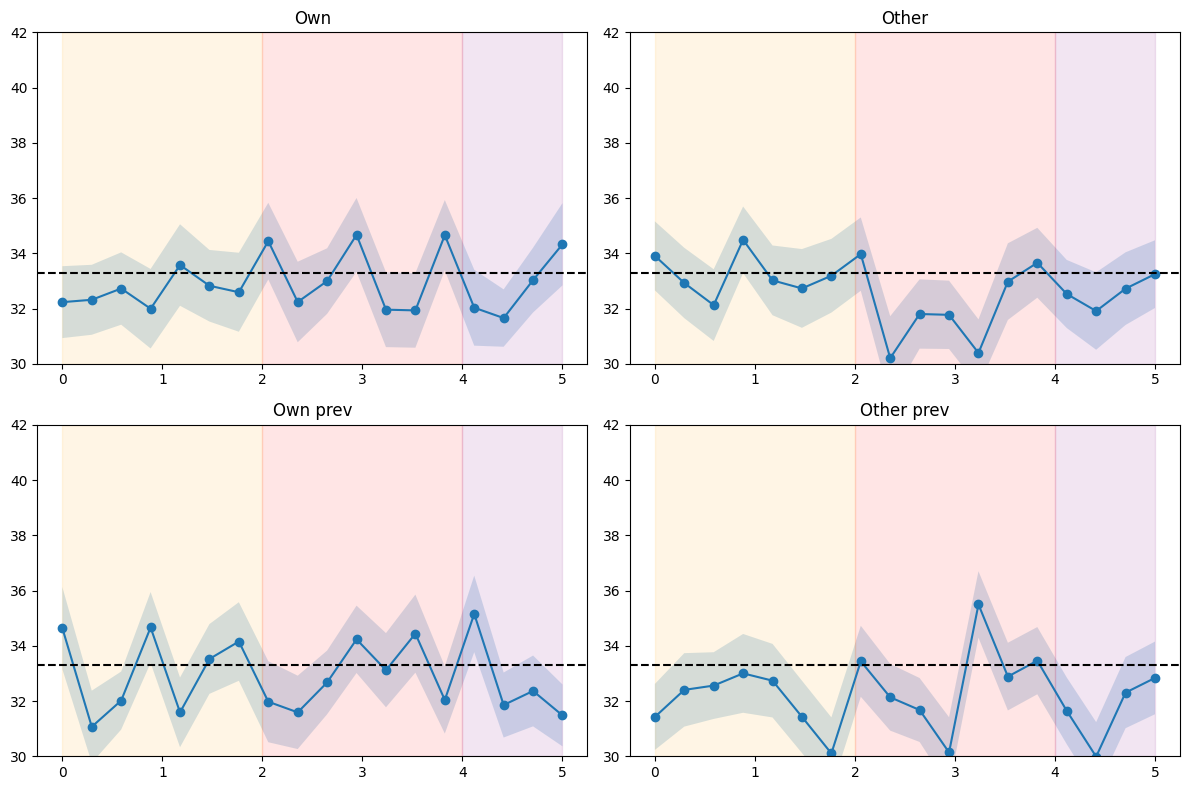

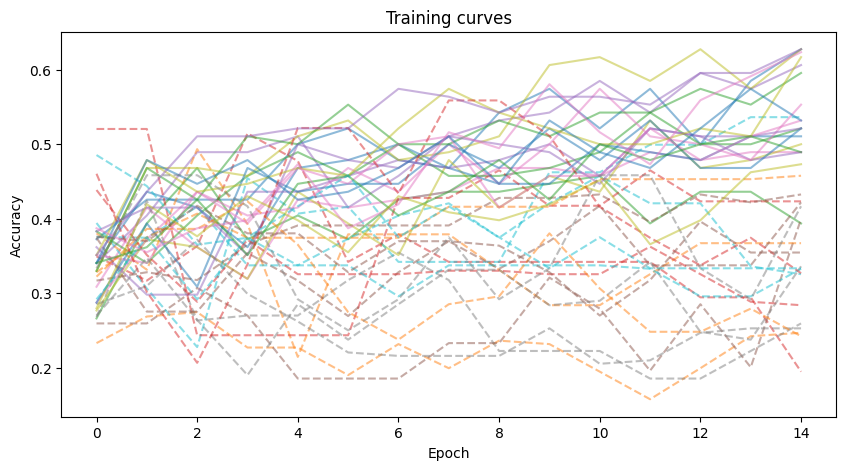

In [62]:
plot_paper([
    np.array(all_results[0]),
    np.array(all_results[1]),
    np.array(all_results[2]),
    np.array(all_results[3]),
])

plot_training(all_curves)